# SALES ANALYSIS

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Import Data

In [4]:
df=pd.read_excel("D:/Data Analysis Projects/Uber project/Uber_SriLanka_Dummy_Data.xlsx")


In [6]:
df.head(10)

,Province,City,Ride Date,Driver Name,Pickup Location,Ride Category,Drop Location,Price (LKR),Rating,Rating Count
0,Northern,Colombo,2023-06-02,Tharindu Peris,Wellawatte,Uber Moto,Unawatuna,2042,4.6,898
1,Southern,Ratnapura,2024-04-29,Kamal Silva,Ella,Uber Moto,Nallur,3684,5.0,3197
2,Central,Kandy,2023-01-22,Kamal Silva,Ella,Uber Moto,Peradeniya,2465,4.0,353
3,Eastern,Negombo,2023-12-09,Ruwan Fernando,Peradeniya,UberX,Wellawatte,1953,4.2,4221
4,North Western,Negombo,2023-05-05,Kamal Silva,Peradeniya,UberX,Peradeniya,2514,4.2,4867
5,Central,Jaffna,2024-05-13,Nimal Perera,Wellawatte,Uber Tuk,Mount Lavinia,4897,4.1,688
6,Western,Galle,2023-02-01,Dinesh Kumara,Nallur,Uber Comfort,Ella,839,4.5,2185
7,Sabaragamuwa,Kandy,2024-06-20,Ruwan Fernando,Kalutara,UberX,Kalutara,1833,5.0,2743
8,Sabaragamuwa,Jaffna,2023-02-28,Pradeep Silva,Ella,Uber Moto,Kalutara,2798,4.2,4146
9,Uva,Negombo,2023-08-18,Ashan Wijesinghe,Wellawatte,Uber Moto,Kalutara,4273,4.2,3674


In [7]:
df.tail()

,Province,City,Ride Date,Driver Name,Pickup Location,Ride Category,Drop Location,Price (LKR),Rating,Rating Count
197425,North Central,Negombo,2024-01-19,Pradeep Silva,Arugam Bay,Uber Tuk,Mount Lavinia,2798,4.8,3080
197426,Sabaragamuwa,Kurunegala,2023-06-03,Dinesh Kumara,Kalutara,Uber Moto,Unawatuna,3048,4.9,2002
197427,Southern,Colombo,2024-04-19,Tharindu Peris,Nallur,Uber Comfort,Unawatuna,673,5.0,3468
197428,Sabaragamuwa,Colombo,2024-10-15,Heshan Lakmal,Wellawatte,UberX,Kalutara,573,3.9,2458
197429,Uva,Badulla,2024-11-21,Nimal Perera,Wellawatte,Uber Tuk,Kalutara,4781,4.6,4615


### Meta Data

In [8]:
print("No of rows:",df.shape[0])

No of rows: 197430


In [10]:
print("No of coloumns:",df.shape[1])

No of coloumns: 10


In [11]:
df.info

<bound method DataFrame.info of              Province        City   Ride Date     Driver Name Pickup Location  \
0            Northern     Colombo  2023-06-02  Tharindu Peris      Wellawatte   
1            Southern   Ratnapura  2024-04-29     Kamal Silva            Ella   
2             Central       Kandy  2023-01-22     Kamal Silva            Ella   
3             Eastern     Negombo  2023-12-09  Ruwan Fernando      Peradeniya   
4       North Western     Negombo  2023-05-05     Kamal Silva      Peradeniya   
...               ...         ...         ...             ...             ...   
197425  North Central     Negombo  2024-01-19   Pradeep Silva      Arugam Bay   
197426   Sabaragamuwa  Kurunegala  2023-06-03   Dinesh Kumara        Kalutara   
197427       Southern     Colombo  2024-04-19  Tharindu Peris          Nallur   
197428   Sabaragamuwa     Colombo  2024-10-15   Heshan Lakmal      Wellawatte   
197429            Uva     Badulla  2024-11-21    Nimal Perera      Wellawatte

### Data types

In [12]:
df.dtypes

Province            object
City                object
Ride Date           object
Driver Name         object
Pickup Location     object
Ride Category       object
Drop Location       object
Price (LKR)          int64
Rating             float64
Rating Count         int64
dtype: object

In [13]:
df.describe()

,Price (LKR),Rating,Rating Count
count,197430.000000,197430.000000,197430.000000
mean,2651.408398,4.249337,2505.159287
std,1355.959116,0.434844,1439.704303
min,300.000000,3.500000,10.000000
25%,1478.000000,3.900000,1262.000000
50%,2651.000000,4.300000,2502.000000
75%,3822.000000,4.600000,3751.000000
max,5000.000000,5.000000,5000.000000


## KPIS

### Total Sales

In [18]:
total_sales=df["Price (LKR)"].sum()
print("total sales:",round(total_sales,2))

total sales: 523467560


### Average Rating

In [20]:
Average_Rating=df["Rating"].mean()
print("total Average:",round(Average_Rating,2))

total Average: 4.25


### Average Order Value

In [21]:
Average_Order_Value=df["Price (LKR)"].mean()
print("Average Order:",round(Average_Order_Value,2))

Average Order: 2651.41


### Rating Count

In [22]:
Rating_Count=df["Rating Count"].sum()
print("Rating Count:",round(Rating_Count,2))

Rating Count: 494593598


Total Orders

In [25]:
total_order=len(df)
print("total orders:",round(total_order,2))

total orders: 197430


# Chart Design

### Monthly Sales Trend

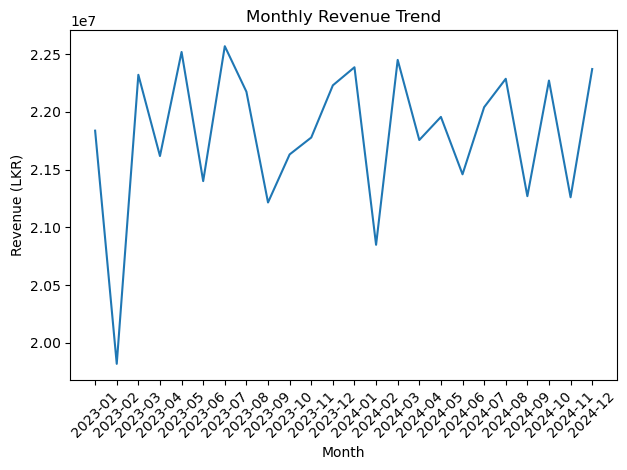

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order Date to datetime
df["Ride Date"] = pd.to_datetime(df["Ride Date"])

# Create YearMonth column
df["YearMonth"] = df["Ride Date"].dt.to_period("M").astype(str)

# Group by YearMonth and calculate monthly revenue
monthly_revenue = df.groupby("YearMonth")["Price (LKR)"].sum().reset_index()

# Plot monthly revenue trend
plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (LKR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (LKR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()


### Daily Sales Trend

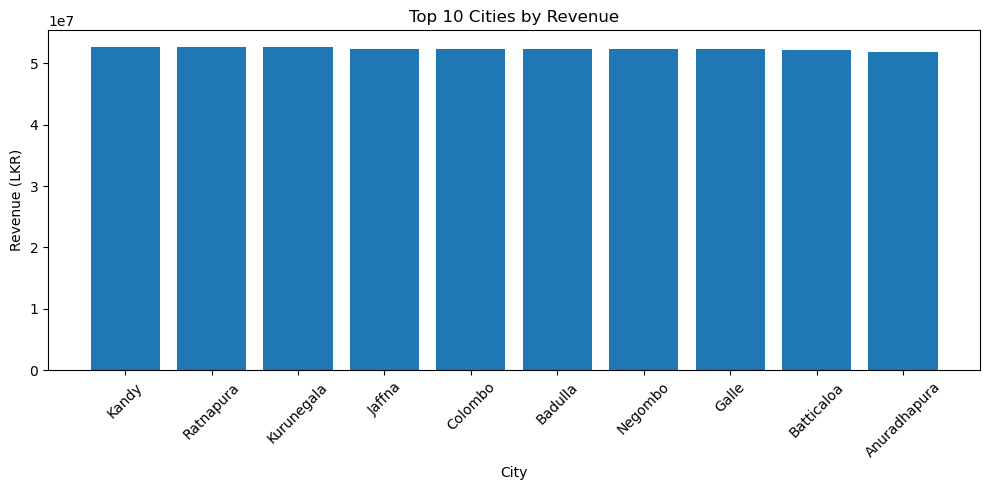

In [33]:
import matplotlib.pyplot as plt

top_cities = (
    df.groupby("City")["Price (LKR)"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(top_cities.index, top_cities.values)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue (LKR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Total Sales by Food type

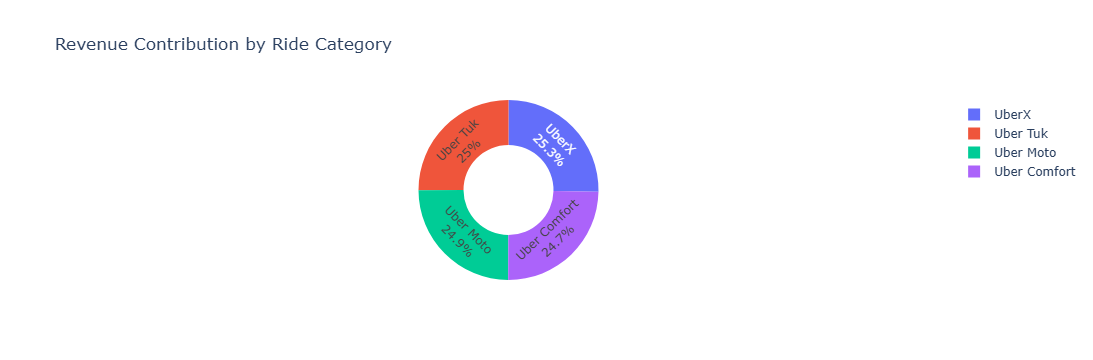

In [31]:
import plotly.express as px

category_revenue = (
    df.groupby("Ride Category")["Price (LKR)"]
      .sum()
      .reset_index()
)

fig = px.pie(
    category_revenue,
    values="Price (LKR)",
    names="Ride Category",
    hole=0.5,
    title="Revenue Contribution by Ride Category"
)

fig.update_traces(textinfo="percent+label")
fig.show()


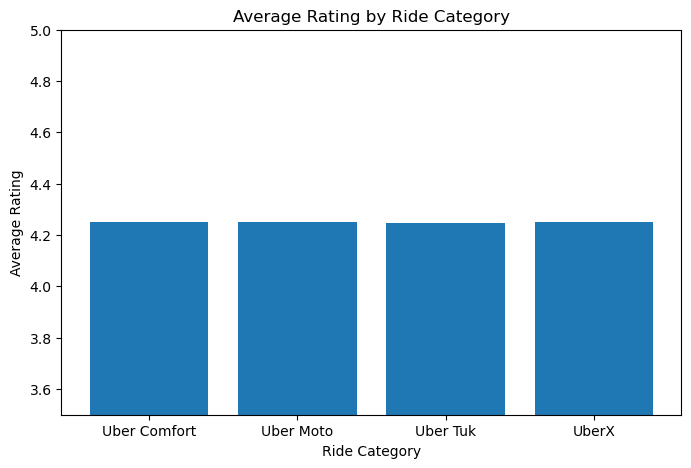

In [34]:
avg_rating = (
    df.groupby("Ride Category")["Rating"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.bar(avg_rating["Ride Category"], avg_rating["Rating"])

plt.title("Average Rating by Ride Category")
plt.xlabel("Ride Category")
plt.ylabel("Average Rating")
plt.ylim(3.5,5)
plt.show()
